In [7]:
import pandas as pd
import numpy as np

# 读取两个CSV文件
# 读取deep_train文件
deep_train_df = pd.read_csv('data/deep_train_202306.csv')

# 读取金佰利数据处理结果文件
kimberly_df = pd.read_csv('金佰利门店信息.csv')

# 查看两个文件的基本信息
print("=== deep_train文件信息 ===")
print(f"数据形状: {deep_train_df.shape}")
print(f"列名: {list(deep_train_df.columns)}")
print("\n前5行数据:")
print(deep_train_df.head())

print("\n" + "="*50 + "\n")

print("=== 金佰利数据处理结果文件信息 ===")
print(f"数据形状: {kimberly_df.shape}")
print(f"列名: {list(kimberly_df.columns)}")
print("\n前5行数据:")
print(kimberly_df.head())

=== deep_train文件信息 ===
数据形状: (39624, 24)
列名: ['start', 'name', 'month', 'predict_3', 'predict_2', 'predict_1', 'predict', 'predict_15', 'predict_14', 'predict_13', 'predict_12', 'mean', 'mean_past', 'standard', 'standard_past', 'predict_3_2', 'predict_2_1', 'predict_3_2_past', 'predict_2_1_past', 'trend_mean', 'trend_mean_past', 'change_1', 'change_2', 'change_3']

前5行数据:
    start       name   month  predict_3  predict_2  predict_1  predict  \
0  202204  中闽百汇泉州涂门店  202204     123611      53987    33372.0  39005.0   
1  202204  中闽百汇泉州涂门店  202205      53987      33372    39005.0  49168.0   
2  202204  中闽百汇泉州涂门店  202206      33372      39005    49168.0  54159.0   
3  202204  中闽百汇泉州涂门店  202207      39005      49168    54159.0  36316.0   
4  202204  中闽百汇泉州涂门店  202208      49168      54159    36316.0  43911.0   

   predict_15  predict_14  predict_13  ...  standard_past  predict_3_2  \
0       85964       34219       76029  ...   27460.047800    -0.563251   
1       34219       76029       

In [29]:
import pandas as pd
import numpy as np

def clean_store_name(store_name):
    """
    清理门店名称，去除括号及括号内的内容，统一格式
    """
    if pd.isna(store_name):
        return store_name
    
    # 转换为字符串并去除前后空格
    store_name_str = str(store_name).strip()
    
    # 去除各种括号及括号内的内容
    import re
    # 匹配 (内容) 格式
    store_name_str = re.sub(r'\([^)]*\)', '', store_name_str)
    # 匹配 ??? 等特殊字符
    store_name_str = re.sub(r'\?+', '', store_name_str)
    # 去除多余的空格
    store_name_str = re.sub(r'\s+', '', store_name_str)
    
    return store_name_str

# 重新读取并处理数据
# 读取deep_train文件
deep_train_df = pd.read_csv('data/deep_train_mz_202208.csv')

# 读取金佰利数据处理结果文件
kimberly_df = pd.read_csv('美赞门店信息_补充渠道信息.csv')

# 清理两个文件中的门店名称
deep_train_df['cleaned_name'] = deep_train_df['name'].apply(clean_store_name)
kimberly_df['cleaned_name'] = kimberly_df['门店名（MJ统一）'].apply(clean_store_name)

# 查看清理后的门店名称样例
print("=== 清理后的门店名称样例 ===")
print("deep_train文件中的门店名称（原名称 -> 清理后名称）:")
sample_deep = deep_train_df[['name', 'cleaned_name']].drop_duplicates('cleaned_name').head(5)
for idx, row in sample_deep.iterrows():
    print(f"  {row['name']} -> {row['cleaned_name']}")

print("\n金佰利文件中的门店名称（原名称 -> 清理后名称）:")
sample_kimberly = kimberly_df[['门店名（MJ统一）', 'cleaned_name']].drop_duplicates('cleaned_name').head(5)
for idx, row in sample_kimberly.iterrows():
    print(f"  {row['门店名（MJ统一）']} -> {row['cleaned_name']}")

# 查看匹配情况
deep_stores = set(deep_train_df['cleaned_name'].unique())
kimberly_stores = set(kimberly_df['cleaned_name'].unique())

matching_stores = deep_stores.intersection(kimberly_stores)
unmatched_deep = deep_stores - kimberly_stores

print(f"\n=== 门店匹配统计 ===")
print(f"deep_train文件中独特门店数量: {len(deep_stores)}")
print(f"金佰利文件中独特门店数量: {len(kimberly_stores)}")
print(f"匹配成功的门店数量: {len(matching_stores)}")
print(f"deep_train中未匹配的门店数量: {len(unmatched_deep)}")

if len(matching_stores) > 0:
    print(f"\n匹配成功的门店示例: {list(matching_stores)[:5]}")

if len(unmatched_deep) > 0:
    print(f"未匹配的门店示例: {list(unmatched_deep)[:5]}")

=== 清理后的门店名称样例 ===
deep_train文件中的门店名称（原名称 -> 清理后名称）:
  10000爱婴岛珠海香洲店 -> 10000爱婴岛珠海香洲店
  10009爱婴岛珠海江湾店 -> 10009爱婴岛珠海江湾店
  10010爱婴岛珠海平沙店 -> 10010爱婴岛珠海平沙店
  10011珠海爱婴岛上冲店 -> 10011珠海爱婴岛上冲店
  10012爱婴岛珠海南水店 -> 10012爱婴岛珠海南水店

金佰利文件中的门店名称（原名称 -> 清理后名称）:
  10000爱婴岛珠海香洲店 -> 10000爱婴岛珠海香洲店
  10001爱婴岛珠海翠桦店 -> 10001爱婴岛珠海翠桦店
  10004爱婴岛珠海吉大店 -> 10004爱婴岛珠海吉大店
  10008爱婴岛珠海斗门店 -> 10008爱婴岛珠海斗门店
  10009爱婴岛珠海江湾店 -> 10009爱婴岛珠海江湾店

=== 门店匹配统计 ===
deep_train文件中独特门店数量: 1935
金佰利文件中独特门店数量: 10796
匹配成功的门店数量: 1935
deep_train中未匹配的门店数量: 0

匹配成功的门店示例: ['天虹商场深圳布吉店', '广州从化蓓蕾婴童百货西宁分店', '丹尼斯（长江店）', '乐友天津欧亚大达商业广场', 'C102757爱婴岛惠州港惠店']


In [37]:
import pandas as pd
import numpy as np

def clean_store_name(store_name):
    """
    清理门店名称，去除括号及括号内的内容，统一格式
    """
    if pd.isna(store_name):
        return store_name
    
    # 转换为字符串并去除前后空格
    store_name_str = str(store_name).strip()
    
    # 去除各种括号及括号内的内容
    import re
    # 匹配 (内容) 格式
    store_name_str = re.sub(r'\([^)]*\)', '', store_name_str)
    # 匹配 ??? 等特殊字符
    store_name_str = re.sub(r'\?+', '', store_name_str)
    # 去除多余的空格
    store_name_str = re.sub(r'\s+', '', store_name_str)
    
    return store_name_str

def merge_store_info(deep_train_path, kimberly_path, output_path):
    """
    将金佰利数据中的门店信息补充到deep_train文件中
    
    参数:
    deep_train_path: deep_train文件路径
    kimberly_path: 金佰利数据处理结果文件路径
    output_path: 输出文件路径
    """
    
    # 1. 读取数据
    print("正在读取数据文件...")
    deep_train_df = pd.read_csv(deep_train_path)
    kimberly_df = pd.read_csv(kimberly_path)
    
    print(f"deep_train数据形状: {deep_train_df.shape}")
    print(f"金佰利数据形状: {kimberly_df.shape}")
    
    # 2. 数据预处理 - 清理门店名称
    print("\n正在清理门店名称...")
    deep_train_df['cleaned_name'] = deep_train_df['name'].apply(clean_store_name)
    kimberly_df['cleaned_name'] = kimberly_df['门店名（MJ统一）'].apply(clean_store_name)
    
    # 3. 准备金佰利数据中的门店信息（只保留门店信息相关列）
    store_info_columns = ['cleaned_name', '大区', '片区', '区域', '品牌渠道']
    store_info_df = kimberly_df[store_info_columns].drop_duplicates('cleaned_name')
    
    # 4. 合并数据（使用左连接，保留deep_train的所有数据）
    print("\n正在合并门店信息...")
    merged_df = pd.merge(
        deep_train_df, 
        store_info_df, 
        on='cleaned_name', 
        how='left',
        suffixes=('', '_kimberly')
    )
    
    # 5. 清理合并后的列（移除辅助列和重复列）
    columns_to_drop = ['cleaned_name', '大区_mz', '片区_mz', '区域_mz', '品牌渠道_mz']
    columns_to_drop = [col for col in columns_to_drop if col in merged_df.columns]
    merged_df = merged_df.drop(columns=columns_to_drop)
    
    # 6. 保存结果
    merged_df.to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f"\n合并完成！结果已保存到: {output_path}")
    
    # 7. 输出合并统计信息
    print("\n=== 合并结果统计 ===")
    print(f"原始数据行数: {len(deep_train_df)}")
    print(f"合并后数据行数: {len(merged_df)}")
    
    # 统计匹配情况
    matched_count = merged_df['区域'].notna().sum()
    unmatched_count = merged_df['区域'].isna().sum()
    
    print(f"\n门店信息匹配情况:")
    print(f"成功匹配门店信息的记录数: {matched_count} ({matched_count/len(merged_df)*100:.2f}%)")
    print(f"未匹配到门店信息的记录数: {unmatched_count} ({unmatched_count/len(merged_df)*100:.2f}%)")
    
    # 统计独特门店匹配情况
    unique_stores_deep = deep_train_df['name'].nunique()
    unique_stores_matched = merged_df[merged_df['区域'].notna()]['name'].nunique()
    
    print(f"\n独特门店匹配情况:")
    print(f"原始独特门店数: {unique_stores_deep}")
    print(f"成功匹配的独特门店数: {unique_stores_matched} ({unique_stores_matched/unique_stores_deep*100:.2f}%)")
    
    # 显示新增的门店信息列
    new_columns = ['大区', '片区', '区域', '品牌渠道']
    print(f"\n新增的门店信息列: {new_columns}")
    
    return merged_df

# 执行门店信息补充
if __name__ == "__main__":
    # 文件路径
    deep_train_path = 'data/deep_train_mz_202303.csv'
    kimberly_path = '美赞门店信息_补充渠道信息.csv'
    output_path = 'data_second/deep_train_mz_202303_with_store_info.csv'
    
    # 执行合并
    result_df = merge_store_info(deep_train_path, kimberly_path, output_path)
    
    # 显示合并后数据的前几行和列名
    print(f"\n=== 合并后数据预览 ===")
    print(f"所有列名: {list(result_df.columns)}")
    print(f"\n前3行数据（显示关键列）:")
    key_columns = ['name', 'month', 'predict', '大区', '区域', '片区', '品牌渠道']
    print(result_df[key_columns].head(3))

正在读取数据文件...
deep_train数据形状: (98787, 25)
金佰利数据形状: (10827, 47)

正在清理门店名称...

正在合并门店信息...

合并完成！结果已保存到: data_second/deep_train_mz_202303_with_store_info.csv

=== 合并结果统计 ===
原始数据行数: 98787
合并后数据行数: 98787

门店信息匹配情况:
成功匹配门店信息的记录数: 98787 (100.00%)
未匹配到门店信息的记录数: 0 (0.00%)

独特门店匹配情况:
原始独特门店数: 1824
成功匹配的独特门店数: 1824 (100.00%)

新增的门店信息列: ['大区', '片区', '区域', '品牌渠道']

=== 合并后数据预览 ===
所有列名: ['start', 'name', 'month', 'mean', 'predict_3', 'predict_2', 'predict_1', 'predict', 'predict_15', 'predict_14', 'predict_13', 'predict_12', 'mean.1', 'mean_past', 'standard', 'standard_past', 'predict_3_2', 'predict_2_1', 'predict_3_2_past', 'predict_2_1_past', 'trend_mean', 'trend_mean_past', 'change_1', 'change_2', 'change_3', '大区', '片区', '区域', '品牌渠道']

前3行数据（显示关键列）:
            name   month    predict   大区    区域   片区 品牌渠道
0  10000爱婴岛珠海香洲店  202111  129441.08  华南区  中山珠海  广佛中  爱婴岛
1  10000爱婴岛珠海香洲店  202112  168291.36  华南区  中山珠海  广佛中  爱婴岛
2  10000爱婴岛珠海香洲店  202201  235514.04  华南区  中山珠海  广佛中  爱婴岛


In [23]:
import pandas as pd
import numpy as np
import re

# 读取CSV文件
df = pd.read_csv('data/4-门店销量数据统计.csv')

# 查看数据基本信息
print("数据基本信息：")
print(f"数据形状：{df.shape}")
print("\n列名：")
print(df.columns.tolist())
print("\n前5行数据：")
print(df.head())
print("\n查看是否有门店相关的列：")
# 查找包含"门店"、"店"等关键词的列
store_columns = [col for col in df.columns if any(keyword in str(col) for keyword in ['门店', '店', '店铺', '网点'])]
print(f"门店相关列：{store_columns}")

if store_columns:
    store_col = store_columns[0]
    print(f"\n使用门店列：{store_col}")
    print(f"\n前10个门店名称：")
    print(df[store_col].head(10))
    print(f"\n唯一门店数量：{df[store_col].nunique()}")
    print(f"\n所有唯一门店名称：")
    unique_stores = df[store_col].unique()
    for i, store in enumerate(unique_stores):
        print(f"{i+1}. {store}")

数据基本信息：
数据形状：(10827, 46)

列名：
['门店名（MJ统一）', '门店编码（MJ）', '门店地址（MJ统一）', '大区', '片区', '区域', '缺失值统计', '202001', '202002', '202003', '202004', '202005', '202006', '202007', '202008', '202009', '202010', '202011', '202012', '202101', '202102', '202103', '202104', '202105', '202106', '202107', '202108', '202109', '202110', '202111', '202112', '202201', '202202', '202203', '202204', '202205', '202206', '202207', '202208', '202209', '202210', '202211', '202212', '202301', '202302', '202303']

前5行数据：
       门店名（MJ统一）  门店编码（MJ）                  门店地址（MJ统一）   大区   片区    区域  缺失值统计  \
0  10000爱婴岛珠海香洲店  11840008               珠海市香洲区柠溪路364号  华南区  广佛中  中山珠海      0   
1  10001爱婴岛珠海翠桦店  11840001              珠海市新香洲敬业路32号一层  华南区  广佛中  中山珠海      0   
2  10004爱婴岛珠海吉大店  11840004  广东省珠海市景山路220号珠海免税商场4楼（爱婴岛）  华南区  广佛中  中山珠海      0   
3  10008爱婴岛珠海斗门店  11840002             珠海斗门区井岸镇朝福路175号  华南区  广佛中  中山珠海      0   
4  10009爱婴岛珠海江湾店  11840201         珠海斗门区井岸镇井湾路318-320号  华南区  广佛中  中山珠海      0   

      202001     2

In [25]:
import pandas as pd
import re
from collections import defaultdict

# 重新读取数据
df = pd.read_csv('data/4-门店销量数据统计.csv')

# 定义品牌渠道识别规则（按优先级排序，越长的品牌名越先匹配）
brand_patterns = [
    # 主要母婴连锁品牌
    ('爱婴岛', re.compile(r'爱婴岛')),
    ('123BABY', re.compile(r'123BABY')),
    ('乐友', re.compile(r'乐友')),
    ('贝贝熊', re.compile(r'贝贝熊')),
    ('孩子王', re.compile(r'孩子王')),
    ('母婴坊', re.compile(r'母婴坊')),
    ('妈仔谷', re.compile(r'妈仔谷')),
    ('宝贝在线', re.compile(r'宝贝在线')),
    ('宝贝计划', re.compile(r'宝贝计划')),
    ('婴知岛', re.compile(r'婴知岛')),
    ('婴唯爱', re.compile(r'婴唯爱')),
    ('宝妈时光', re.compile(r'宝妈时光')),
    ('美贝美妈', re.compile(r'美贝美妈')),
    ('金摇篮', re.compile(r'金摇篮')),
    ('金色时光', re.compile(r'金色时光')),
    ('爸爸爱', re.compile(r'爸爸爱')),
    ('妈妈之吻', re.compile(r'妈妈之吻')),
    ('亲亲宝贝', re.compile(r'亲亲宝贝')),
    ('漂亮宝贝', re.compile(r'漂亮宝贝')),
    ('好宝宝', re.compile(r'好宝宝')),
    ('萌宝家', re.compile(r'萌宝家')),
    ('家贝爱', re.compile(r'家贝爱')),
    ('母婴屋', re.compile(r'母婴屋')),
    ('婴儿用品', re.compile(r'婴儿用品|母婴用品')),
    ('孕婴童', re.compile(r'孕婴童|孕婴')),
    ('乐茵', re.compile(r'乐茵')),
    ('天爱儿童', re.compile(r'天爱儿童')),
    ('健瑞儿', re.compile(r'健瑞儿')),
    ('爱婴坊', re.compile(r'爱婴坊')),
    ('爱婴室', re.compile(r'爱婴室')),
    
    # 大型超市渠道
    ('沃尔玛', re.compile(r'沃尔玛')),
    ('家乐福', re.compile(r'家乐福')),
    ('永辉超市', re.compile(r'永辉超市|永辉')),
    ('欧尚', re.compile(r'欧尚')),
    ('易初莲花', re.compile(r'易初莲花')),
    ('乐购', re.compile(r'乐购')),
    
    # 其他识别
    ('妈咪爱', re.compile(r'妈咪爱')),
    ('小龙哈比', re.compile(r'小龙哈比')),
    ('祺美柔', re.compile(r'祺美柔')),
    ('婴之爱', re.compile(r'婴之爱')),
    ('华亿母婴', re.compile(r'华亿母婴')),
    ('恒大', re.compile(r'恒大')),  # 可能是恒大相关渠道
]

def identify_channel(store_name):
    """根据门店名称识别渠道品牌"""
    if pd.isna(store_name):
        return '未知渠道'
    
    store_name_str = str(store_name).strip()
    
    # 按优先级匹配品牌
    for brand, pattern in brand_patterns:
        if pattern.search(store_name_str):
            return brand
    
    # 如果都不匹配，根据门店名称特征分类
    if '母婴' in store_name_str or '婴' in store_name_str or '宝' in store_name_str:
        return '其他母婴店'
    elif '超市' in store_name_str or '商场' in store_name_str or '购物' in store_name_str:
        return '其他超市/商场'
    else:
        return '其他渠道'

# 应用渠道识别函数
df['品牌渠道'] = df['门店名（MJ统一）'].apply(identify_channel)

# 统计各渠道的门店数量
channel_count = df['品牌渠道'].value_counts().reset_index()
channel_count.columns = ['品牌渠道', '门店数量']

print("各品牌渠道门店数量统计：")
print("="*50)
for idx, row in channel_count.iterrows():
    print(f"{idx+1:2d}. {row['品牌渠道']:12s} - {row['门店数量']:5d} 家门店")

print(f"\n总计门店数量：{len(df)} 家")
print(f"识别出的渠道数量：{len(channel_count)} 个")

# 查看每个渠道的部分门店示例
print("\n" + "="*60)
print("各渠道门店名称示例：")
print("="*60)

for channel in channel_count['品牌渠道'].head(10):  # 显示前10个渠道的示例
    sample_stores = df[df['品牌渠道'] == channel]['门店名（MJ统一）'].head(3).tolist()
    print(f"\n【{channel}】（共{channel_count[channel_count['品牌渠道']==channel]['门店数量'].iloc[0]}家）：")
    for i, store in enumerate(sample_stores, 1):
        print(f"  {i}. {store}")

# 保存补充渠道信息后的文件
output_file = '美赞门店信息_补充渠道信息.csv'
df.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"\n文件已保存至：{output_file}")
print(f"\n新增列 '品牌渠道' 已添加到数据集中，位于最后一列。")

各品牌渠道门店数量统计：
 1. 其他渠道         -  4234 家门店
 2. 其他母婴店        -  2642 家门店
 3. 孕婴童          -   531 家门店
 4. 爱婴岛          -   436 家门店
 5. 孩子王          -   431 家门店
 6. 沃尔玛          -   365 家门店
 7. 其他超市/商场      -   353 家门店
 8. 乐友           -   289 家门店
 9. 爱婴室          -   254 家门店
10. 婴儿用品         -   199 家门店
11. 永辉超市         -   168 家门店
12. 贝贝熊          -   158 家门店
13. 家乐福          -    95 家门店
14. 宝贝在线         -    83 家门店
15. 爱婴坊          -    81 家门店
16. 欧尚           -    68 家门店
17. 妈仔谷          -    58 家门店
18. 母婴坊          -    52 家门店
19. 健瑞儿          -    50 家门店
20. 易初莲花         -    46 家门店
21. 亲亲宝贝         -    39 家门店
22. 婴知岛          -    37 家门店
23. 乐购           -    24 家门店
24. 妈咪爱          -    23 家门店
25. 金摇篮          -    21 家门店
26. 宝贝计划         -    19 家门店
27. 漂亮宝贝         -    16 家门店
28. 123BABY      -     9 家门店
29. 金色时光         -     9 家门店
30. 美贝美妈         -     5 家门店
31. 婴之爱          -     5 家门店
32. 恒大           -     5 家门店
33. 婴唯爱          -     4 家门店
34. 好宝宝          -     3 家门店
3

findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of 

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/品牌渠道门店数量分析图.png'

findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of 

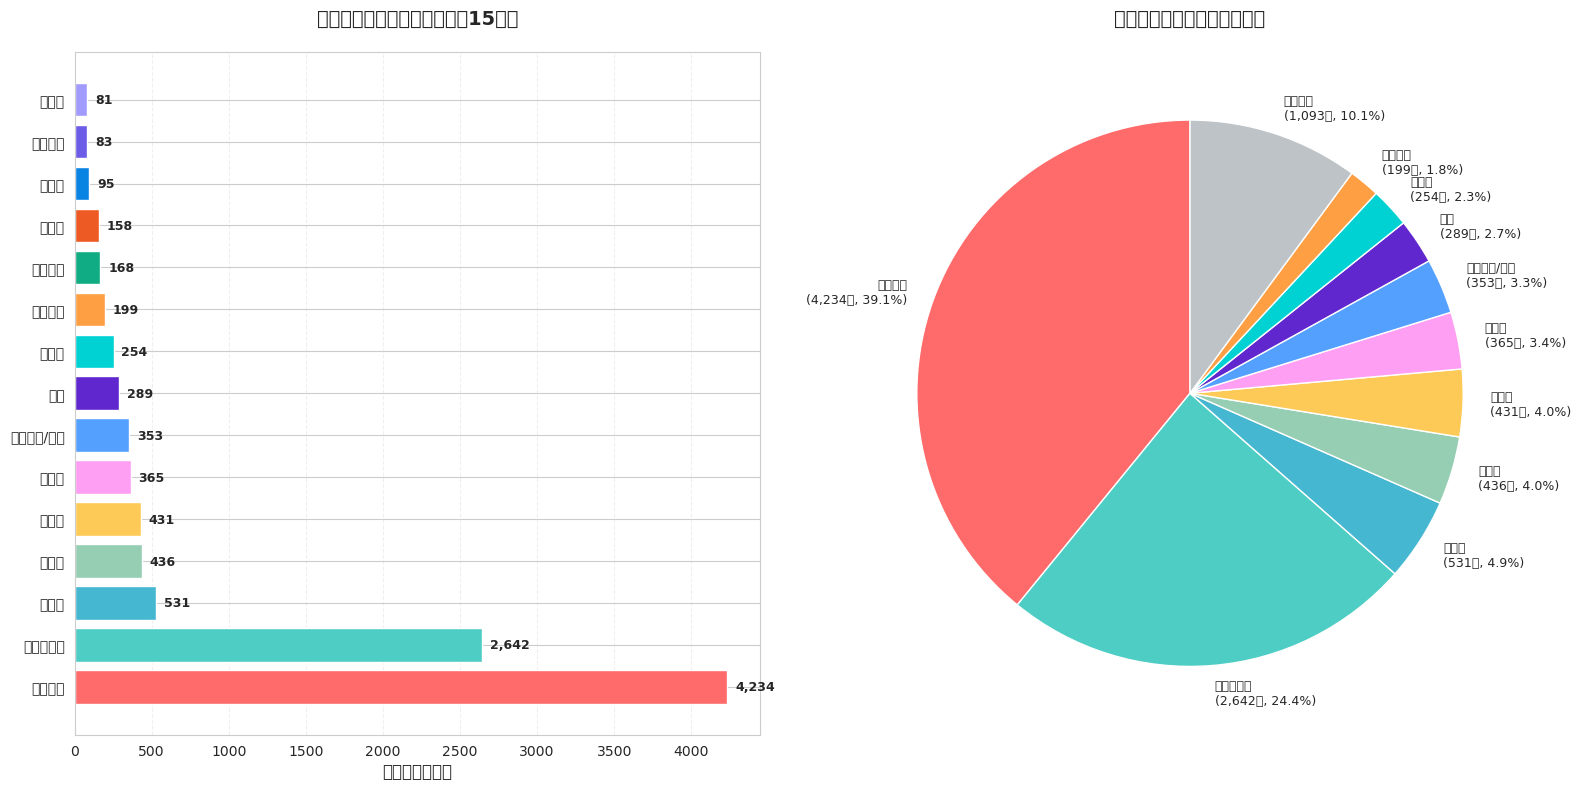

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei']
plt.rcParams['axes.unicode_minus'] = False

# 读取处理后的数据
df = pd.read_csv('美赞门店信息_补充渠道信息.csv')

# 1. 统计各渠道门店数量并排序（取前15名，其他归为"其他"）
channel_counts = df['品牌渠道'].value_counts()
top_15_channels = channel_counts.head(15)
other_count = channel_counts[15:].sum()

# 准备绘图数据
plot_data = top_15_channels.copy()
if other_count > 0:
    plot_data['其他小渠道'] = other_count

# 创建图表
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# 定义颜色方案
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', 
          '#FF9FF3', '#54A0FF', '#5F27CD', '#00D2D3', '#FF9F43',
          '#10AC84', '#EE5A24', '#0984E3', '#6C5CE7', '#A29BFE', '#BDC3C7']

# 左图：水平条形图（前15名渠道）
bars1 = ax1.barh(range(len(top_15_channels)), top_15_channels.values, color=colors[:len(top_15_channels)])
ax1.set_yticks(range(len(top_15_channels)))
ax1.set_yticklabels(top_15_channels.index, fontsize=10)
ax1.set_xlabel('门店数量（家）', fontsize=12, fontweight='bold')
ax1.set_title('各品牌渠道门店数量分布（前15名）', fontsize=14, fontweight='bold', pad=20)
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# 在条形图上添加数值标签
for i, (bar, value) in enumerate(zip(bars1, top_15_channels.values)):
    ax1.text(value + 50, bar.get_y() + bar.get_height()/2, 
             f'{value:,}', va='center', fontsize=9, fontweight='bold')

# 右图：饼图（显示主要渠道占比）
# 只显示占比超过2%的渠道，其他归为"其他"
pie_data = []
pie_labels = []
pie_colors = []
other_pie_count = 0

for i, (channel, count) in enumerate(channel_counts.items()):
    percentage = count / len(df) * 100
    if percentage >= 2 or i < 10:  # 显示占比2%以上或前10名
        pie_data.append(count)
        pie_labels.append(f'{channel}\n({count:,}家, {percentage:.1f}%)')
        pie_colors.append(colors[i % len(colors)])
    else:
        other_pie_count += count

if other_pie_count > 0:
    other_percentage = other_pie_count / len(df) * 100
    pie_data.append(other_pie_count)
    pie_labels.append(f'其他渠道\n({other_pie_count:,}家, {other_percentage:.1f}%)')
    pie_colors.append('#BDC3C7')

# 绘制饼图
wedges, texts, autotexts = ax2.pie(pie_data, labels=pie_labels, colors=pie_colors, 
                                   autopct='', startangle=90, textprops={'fontsize': 9})
ax2.set_title('各品牌渠道门店数量占比分布', fontsize=14, fontweight='bold', pad=20)

# 调整布局
plt.tight_layout()
plt.savefig('品牌渠道门店数量分析图.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.close()

# 2. 生成详细的渠道统计报告
report_data = []
for channel, count in channel_counts.items():
    percentage = count / len(df) * 100
    # 获取该渠道的示例门店（前3个）
    sample_stores = df[df['品牌渠道'] == channel]['门店名（MJ统一）'].head(3).tolist()
    sample_str = ' | '.join(sample_stores) if sample_stores else '无'
    
    report_data.append({
        '渠道排名': len(report_data) + 1,
        '品牌渠道': channel,
        '门店数量': count,
        '占比(%)': round(percentage, 2),
        '示例门店': sample_str
    })

# 创建报告DataFrame
report_df = pd.DataFrame(report_data)

# 保存报告
report_df.to_excel('品牌渠道识别报告.xlsx', index=False, engine='openpyxl')

# 显示汇总信息
print("="*80)
print("品牌渠道识别任务完成汇总")
print("="*80)
print(f"• 总数据量：{len(df):,} 条门店记录")
print(f"• 识别出渠道数量：{len(channel_counts)} 个")
print(f"• 主要渠道分布（占比≥5%）：")
major_channels = channel_counts[channel_counts / len(df) >= 0.05]
for channel, count in major_channels.items():
    percentage = count / len(df) * 100
    print(f"  - {channel}: {count:,} 家门店 ({percentage:.1f}%)")
print(f"• 数据完整性：100% 门店均已分配渠道")
print("="*80)
print("\n生成的文件：")
print("1. 补充渠道信息的数据文件：4-门店销量数据统计_补充渠道信息.csv")
print("2. 渠道分析图表：品牌渠道门店数量分析图.png") 
print("3. 详细识别报告：品牌渠道识别报告.xlsx")
print("="*80)

# 显示前10名渠道的详细信息
print("\n前10名品牌渠道详细信息：")
print("-"*80)
for i, row in report_df.head(10).iterrows():
    print(f"{row['渠道排名']:2d}. {row['品牌渠道']:12s} | {row['门店数量']:6,} 家 | {row['占比(%)']:5.2f}% | 示例：{row['示例门店']}")